In [11]:
from pyrootmemo import Parameter
from pyrootmemo.materials import MultipleRoots
from pyrootmemo.geometry import FailureSurface
from pyrootmemo.models import Fbm

# Fibre Bundle Model (FBM)

The Fibre Bundle Model (FBM) assumes all roots break in tension and allows for
incorporating the effect of sequential root breakage on reinforcement 
predictions.

In FBMs, the total force is distributed over all intact roots according to a 
load sharing parameter $\beta_F$:

$$ \frac{T_i}{T_j} = \left(\frac{D_i}{D_j}\right)^{\beta_F} $$

where $T$ and $D$ are the tensile forces and diameters of any intact roots $i$ 
and $j$.

Common values for $\beta_F$ are:

| $\beta_F$ | Phyiscal meaning |
|---|---|
| 0 | equal tensile force in each root |
| 1 | force proportional to root diameter |
| 2 | equal tensile stress in each root |

However, any value of $\beta_F$ is permissible. For a detailed discussion on 
the effect of load sharing parameter and alternatives to the values above, 
see [Meijer (2021)](https://doi.org/10.1007/s11104-021-05039-z).

## Create a model object

Define some roots, using the `MultipleRoots` class. The FBM model requires the 
following root attributes to be defined:

* Root diameter: (`diameter`)
* Root tensile strength (`tensile strength`)

In [12]:
roots = MultipleRoots(
    species = 'test_species',
    diameter = Parameter([2, 3, 4, 5], 'mm'),
    tensile_strength = Parameter([500, 250, 100, 50], 'MPa')
    )

Next, create an instance of the FBM model class, for example choosing a 
load-sharing factor $\beta_F=2$:

In [13]:
fbm = Fbm(roots, load_sharing = 2.0)

## Calculations

Various calculations can be made. All results are stored in dictionary object 
in the `output` attribute of the class.

### Peak force (`peak_force`)

To calculate the total maximum tensile force the bundle of roots can carry
, first do the calculation and then request the results from the `output` 
attribute:

In [14]:
fbm.calc_peak_force()
print(fbm.output['peak_force'])

2552.544031041707 megapascal * millimeter ** 2


Calculation output can easily be converted to different units. For example,, 
to convert the calculated peak force to kilonewtons:

In [15]:
print(fbm.output['peak_force'].to('kN'))

2.552544031041707 kilonewton


### Peak reinforcement (`peak_reinforcement`)

To calculate the peak reinforcement, the cross-sectional area of the failure
surface is required. A failure surface can be defined using the 
`FailureSurface` class:  

In [16]:
failure_surface = FailureSurface(cross_sectional_area = Parameter(2, 'm^2'))

Secondly, the orienation factor $k'$ should be defined (similar to in the 
Wu/Waldron model), which depends on the  orientation of the roots at failure 
and the angle of internal friction of the soil. By default, this set to 
$k'=1.0$ in line with most studies, but can be adjusted, for example

In [17]:
fbm.calc_peak_reinforcement(failure_surface, k = 1.2)
print(fbm.output['peak_reinforcement'])
print(fbm.output['peak_reinforcement'].to('kPa'))

1531.5264186250242 megapascal * millimeter ** 2 / meter ** 2
1.5315264186250244 kilopascal


### Reduction factor compared to WWM (`reduction_factor`)

The FBM always calculates equal or smaller reinforcements compared calculations
made assuming all roots catastropically break at the same time. The reduction 
factor $k''$:

$$ k'' = \frac{\text{peak force}_{\text{FBM}}}{\text{peak force}_{\text{catastropic}}} $$


In [18]:
fbm.calc_reduction_factor()
print(fbm.output['reduction_factor'])

0.4577464788732394


## Plotting (`plot`)

The results of the FBM can be plotted using the `plot()` method.

The total force in the bundle (y-axis) is plotted against the force in the 
so-called 'reference root': a hypothetical root that will never break and has a 
diameter equal to a reference diameter, by default 1 mm. This 'reference force' 
can be seen as a proxy for strain or time.

To create a basic plot:

<Axes: xlabel='Force in reference root [N]', ylabel='Total force in root bundle [N]'>

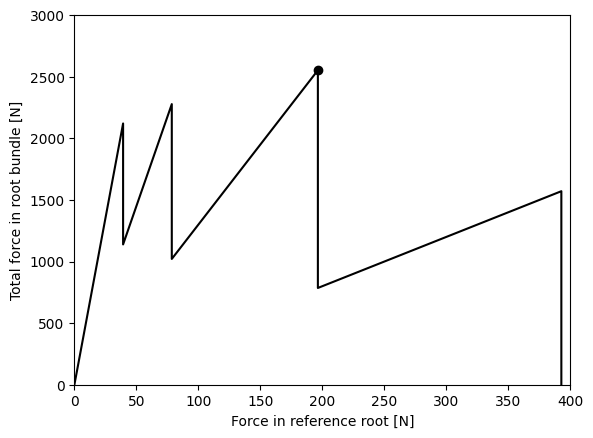

In [19]:
fbm.plot()

You can also request to see the contribution of each individual root, and/or add labels 
indicate the index of the root in the `MultipleRoots` object, i.e. the order in
which they were defined. 

<Axes: xlabel='Force in reference root [N]', ylabel='Total force in root bundle [N]'>

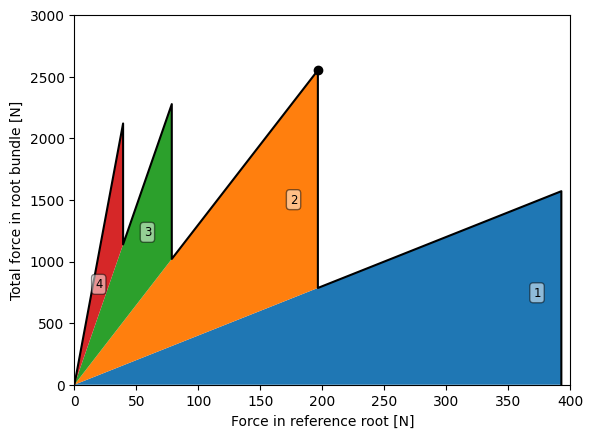

In [20]:
fbm.plot(stack = True, labels = True)